Лаб №6. (дизбаланс)

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.patches as mpatches
import time
import collections
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from scipy.stats import norm
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
df = pd.read_csv('/content/drive/MyDrive/paddydataset.csv')
print("Информация о датасете:")
df.head()

Информация о датасете:


,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [11]:
df.describe()

,Hectares,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,Weed28D_thiobencarb,Urea_40Days,Potassh_50Days,Micronutrients_70Days,...,Inst Wind Speed_D1_D30(in Knots),Inst Wind Speed_D31_D60(in Knots),Inst Wind Speed_D61_D90(in Knots),Inst Wind Speed_D91_D120(in Knots),Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
count,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,...,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000,2789.000000
mean,3.717461,92.936536,46.468268,74.349229,3.717461,148.698458,7.434923,100.854729,38.587250,55.761922,...,7.233417,8.512729,8.172822,9.449265,76.256938,87.594120,85.160272,83.859448,335.510936,22517.728935
std,1.437777,35.944420,17.972210,28.755536,1.437777,57.511072,2.875554,39.006885,14.924123,21.566652,...,2.566549,3.203679,1.993596,2.516664,8.001361,6.776736,3.492529,3.134875,134.314772,9199.661393
min,1.000000,25.000000,12.500000,20.000000,1.000000,40.000000,2.000000,27.130000,10.380000,15.000000,...,4.000000,4.000000,4.000000,6.000000,64.600000,78.000000,81.000000,79.000000,80.000000,5410.000000
25%,3.000000,75.000000,37.500000,60.000000,3.000000,120.000000,6.000000,81.390000,31.140000,45.000000,...,4.000000,6.000000,8.000000,6.000000,72.000000,80.000000,83.000000,81.000000,240.000000,16389.000000
50%,4.000000,100.000000,50.000000,80.000000,4.000000,160.000000,8.000000,108.520000,41.520000,60.000000,...,8.000000,10.000000,8.000000,10.000000,72.700000,91.000000,84.000000,84.000000,360.000000,24636.000000
75%,5.000000,125.000000,62.500000,100.000000,5.000000,200.000000,10.000000,135.650000,51.900000,75.000000,...,10.000000,12.000000,10.000000,12.000000,85.000000,95.000000,88.000000,87.000000,450.000000,31035.000000
max,6.000000,150.000000,75.000000,120.000000,6.000000,240.000000,12.000000,162.780000,62.280000,90.000000,...,10.000000,12.000000,10.000000,12.000000,88.500000,96.000000,92.000000,88.000000,600.000000,38814.000000


In [12]:
df.isnull().sum()

,0
Hectares,0
Agriblock,0
Variety,0
Soil Types,0
Seedrate(in Kg),0
LP_Mainfield(in Tonnes),0
Nursery,0
Nursery area (Cents),0
LP_nurseryarea(in Tonnes),0
DAP_20days,0


In [13]:
df.columns

Index(['Hectares ', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)',
       'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)',
       'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb',
       'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days',
       'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)',
       '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)',
       '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)',
       'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60',
       'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90',
       'Min temp_D91_D120', 'Max temp_D91_D120',
       'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)',
       'Inst Wind Speed_D61_D90(in Knots)',
       'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30',
       'Wind Direction_D31_D60', 'Wind Direction_D61_D90',
       'Wind Direction_D91_D120', 'Relative Humidity_D1_D30',
       'Relative Humi

Пункт 1.

In [20]:
print("Оригинальный датасет:")
print(f"  Размер: {df.shape}")
print(f"  Всего записей: {len(df)}")

df_fraud = df.copy()

yield_col = None
for col in df_fraud.columns:
    if 'yield' in col.lower() or 'Paddy' in col:
        yield_col = col
        break

if yield_col is None:
    numeric_cols = df_fraud.select_dtypes(include=[np.number]).columns
    yield_col = numeric_cols[-1]

print(f"Целевая колонка (урожайность): '{yield_col}'")

fraud_ratio = 0.05
n_fraud = int(len(df_fraud) * fraud_ratio)

df_fraud['is_fraud'] = 0

np.random.seed(42)
fraud_indices = np.random.choice(len(df_fraud), n_fraud, replace=False)

original_values = df_fraud.loc[fraud_indices, yield_col].copy()

for idx in fraud_indices:
    fraud_type = np.random.choice(['high', 'low', 'extreme'])

    if fraud_type == 'high':
        df_fraud.loc[idx, yield_col] *= np.random.uniform(1.5, 3.0)
    elif fraud_type == 'low':
        df_fraud.loc[idx, yield_col] /= np.random.uniform(2.0, 5.0)
    else:
        df_fraud.loc[idx, yield_col] = np.random.uniform(
            df_fraud[yield_col].min() * 0.5,
            df_fraud[yield_col].max() * 1.5
        )

    df_fraud.loc[idx, 'is_fraud'] = 1

print("ДАТАСЕТ С ИСКУССТВЕННЫМИ МОШЕННИЧЕСКИМИ ТРАНЗАКЦИЯМИ")
print(f"  Обычные транзакции: {(df_fraud['is_fraud'] == 0).sum()} ({(1-fraud_ratio)*100:.1f}%)")
print(f"  Мошеннические транзакции: {(df_fraud['is_fraud'] == 1).sum()} ({fraud_ratio*100:.1f}%)")
print(f"  Всего записей: {len(df_fraud)}")

Оригинальный датасет:
  Размер: (2789, 45)
  Всего записей: 2789
Целевая колонка (урожайность): 'Paddy yield(in Kg)'
ДАТАСЕТ С ИСКУССТВЕННЫМИ МОШЕННИЧЕСКИМИ ТРАНЗАКЦИЯМИ
  Обычные транзакции: 2650 (95.0%)
  Мошеннические транзакции: 139 (5.0%)
  Всего записей: 2789


In [25]:
if 'class' in df.columns:
    print("РАСПРЕДЕЛЕНИЕ КЛАССОВ УРОЖАЙНОСТИ")
    class_counts = df['class'].value_counts()
    for class_name, count in class_counts.items():
        percentage = count / len(df) * 100
        print(f"  {class_name}: {count} записей ({percentage:.2f}%)")
else:
    print("Колонка 'class' не найдена! Создаем классы на основе урожайности...")
    yield_col = None
    for col in df.columns:
        if 'yield' in col.lower() or 'Paddy' in col:
            yield_col = col
            break

    if yield_col:
        df['class'] = pd.qcut(df[yield_col], q=3, labels=['Low', 'Medium', 'High'])

        print("РАСПРЕДЕЛЕНИЕ КЛАССОВ УРОЖАЙНОСТИ")

        class_counts = df['class'].value_counts()
        for class_name, count in class_counts.items():
            percentage = count / len(df) * 100
            print(f"  {class_name}: {count} записей ({percentage:.2f}%)")

        print(f"\n  Всего записей: {len(df)}")

РАСПРЕДЕЛЕНИЕ КЛАССОВ УРОЖАЙНОСТИ
  Low: 950 записей (34.06%)
  High: 923 записей (33.09%)
  Medium: 916 записей (32.84%)


In [27]:
n_trans = round((df_fraud['is_fraud'] == 0).sum() / len(df_fraud) * 100, 2)
f_trans = round((df_fraud['is_fraud'] == 1).sum() / len(df_fraud) * 100, 2)

print(f'Обычные транзакции составляют {n_trans} % данных')
print(f'Мошеннические транзакции составляют {f_trans} % данных')

Обычные транзакции составляют 95.02 % данных
Мошеннические транзакции составляют 4.98 % данных


Пункт 2. Визуализация

Text(0.5, 1.0, 'Распределение классов \n (0: Не мошенник || 1: Мошенник)')

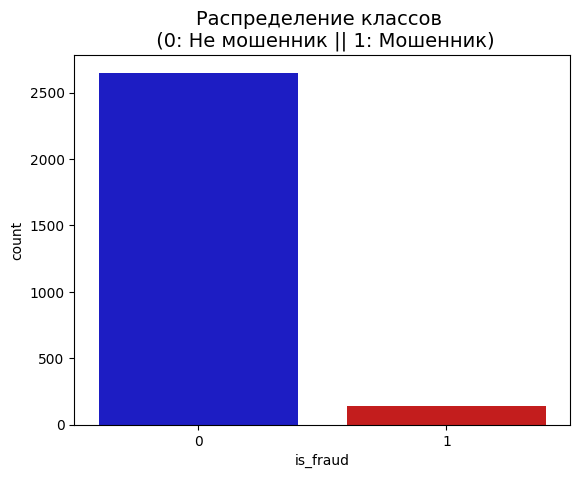

In [28]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='is_fraud', data=df_fraud, palette=colors)
plt.title('Распределение классов \n (0: Не мошенник || 1: Мошенник)', fontsize=14)

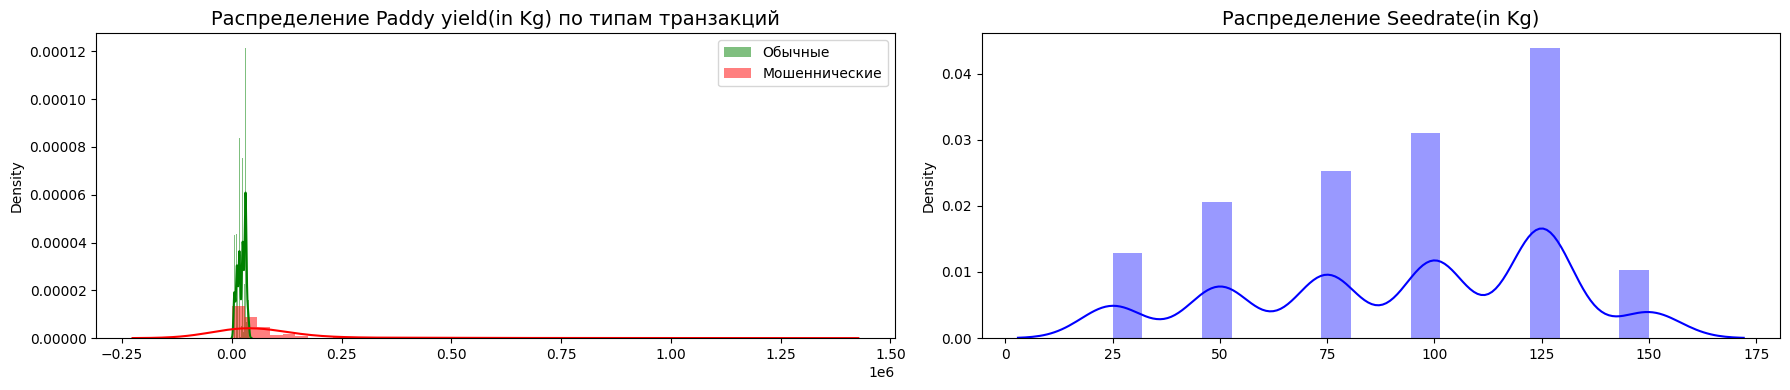

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

if 'is_fraud' in df_fraud.columns:
    normal = df_fraud[df_fraud['is_fraud'] == 0][yield_col].values
    fraud = df_fraud[df_fraud['is_fraud'] == 1][yield_col].values

    sns.distplot(normal, ax=ax[0], color='g', label='Обычные', hist_kws={'alpha':0.5})
    sns.distplot(fraud, ax=ax[0], color='r', label='Мошеннические', hist_kws={'alpha':0.5})
    ax[0].set_title(f'Распределение {yield_col} по типам транзакций', fontsize=14)
    ax[0].legend()

    col2 = 'Seedrate(in Kg)' if 'Seedrate(in Kg)' in df_fraud.columns else df_fraud.columns[1]
    values2 = df_fraud[col2].values
    sns.distplot(values2, ax=ax[1], color='b')
    ax[1].set_title(f'Распределение {col2}', fontsize=14)

plt.tight_layout()
plt.show()

Пункт 3. Разделение данных

In [32]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

label_col = 'is_fraud' if 'is_fraud' in df_fraud.columns else 'class'

feature_cols = df_fraud.select_dtypes(include=[np.number]).columns.tolist()
if label_col in feature_cols:
    feature_cols.remove(label_col)

X = df_fraud[feature_cols]
y = df_fraud[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Распределение классов:")
print(f"  Обучающий набор: {np.bincount(y_train)}")
print(f"  Тестовый набор: {np.bincount(y_test)}")
print(f"  X_train shape: {X_train_scaled.shape}")
print(f"  X_test shape: {X_test_scaled.shape}")

Распределение классов:
  Обучающий набор: [2120  111]
  Тестовый набор: [530  28]
  X_train shape: (2231, 37)
  X_test shape: (558, 37)


Используем существующую колонку 'is_fraud'

Распределение:
  Обычные (0): 2650 записей
  Мошеннические (1): 139 записей

Выбранные столбцы для корреляции:
  1. Hectares 
  2. Seedrate(in Kg)
  3. LP_Mainfield(in Tonnes)
  4. Nursery area (Cents)
  5. LP_nurseryarea(in Tonnes)
  6. DAP_20days
  7. Weed28D_thiobencarb
  8. Urea_40Days
  9. Potassh_50Days
  10. class_binary


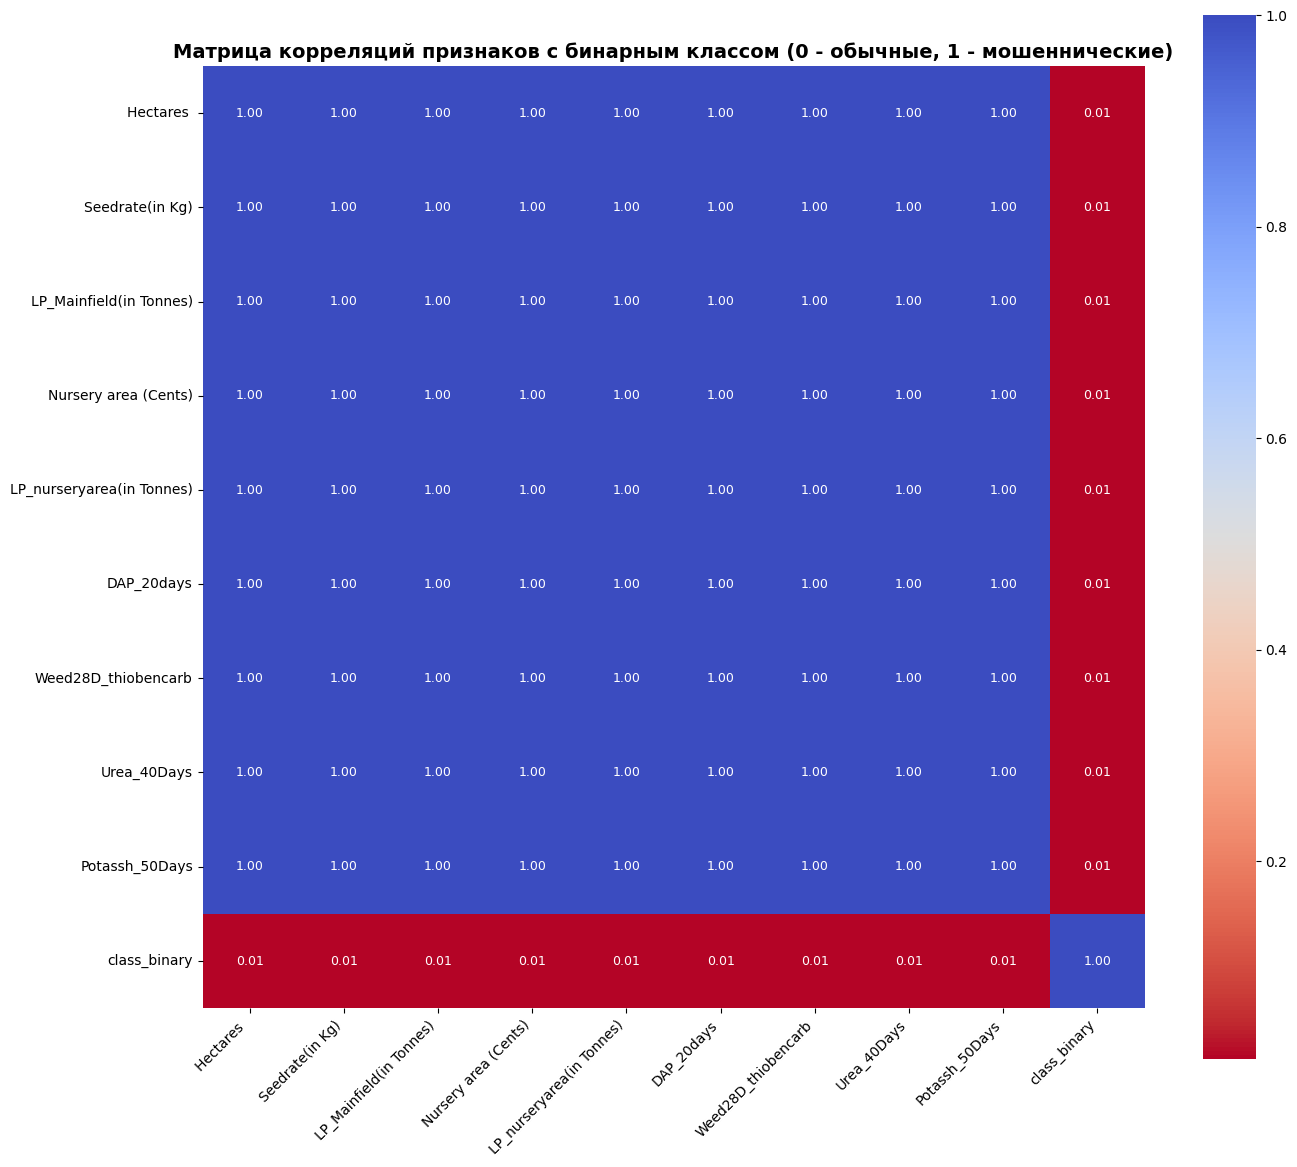

КОРРЕЛЯЦИЯ С БИНАРНЫМ КЛАССОМ (class_binary)
Nursery area (Cents)         0.012921
DAP_20days                   0.012921
LP_Mainfield(in Tonnes)      0.012921
Seedrate(in Kg)              0.012921
Urea_40Days                  0.012921
Hectares                     0.012921
LP_nurseryarea(in Tonnes)    0.012921
Weed28D_thiobencarb          0.012921
Potassh_50Days               0.012921
Name: class_binary, dtype: float64
ТОП-5 ПРИЗНАКОВ С ПОЛОЖИТЕЛЬНОЙ КОРРЕЛЯЦИЕЙ (связаны с мошенничеством)
  Nursery area (Cents): 0.0129
  DAP_20days: 0.0129
  LP_Mainfield(in Tonnes): 0.0129
  Seedrate(in Kg): 0.0129
  Urea_40Days: 0.0129
ТОП-5 ПРИЗНАКОВ С ОТРИЦАТЕЛЬНОЙ КОРРЕЛЯЦИЕЙ (связаны с обычными транзакциями)


In [38]:
dataset_numeric = df_fraud.copy()
if 'class' in dataset_numeric.columns:
    print("Уникальные значения в class:", dataset_numeric['class'].unique())

    dataset_numeric['class_binary'] = dataset_numeric['class'].map({
        'Low': 0,
        'Medium': 0,
        'High': 1
    })

    print("После преобразования в бинарный класс:", dataset_numeric['class_binary'].unique())
    print(f"\nРаспределение бинарных классов:")
    print(f"  Обычные (0): {(dataset_numeric['class_binary'] == 0).sum()} записей")
    print(f"  Мошеннические (1): {(dataset_numeric['class_binary'] == 1).sum()} записей")

elif 'is_fraud' in dataset_numeric.columns:
    dataset_numeric['class_binary'] = dataset_numeric['is_fraud']
    print("Используем существующую колонку 'is_fraud'")
    print(f"\nРаспределение:")
    print(f"  Обычные (0): {(dataset_numeric['class_binary'] == 0).sum()} записей")
    print(f"  Мошеннические (1): {(dataset_numeric['class_binary'] == 1).sum()} записей")

numeric_columns = dataset_numeric.select_dtypes(include=['float64', 'int64']).columns

if 'class_binary' not in numeric_columns:
    numeric_columns = list(numeric_columns) + ['class_binary']

numeric_cols_without_class = [col for col in numeric_columns if col != 'class_binary']
first_9_numeric = numeric_cols_without_class[:9]
selected_columns = first_9_numeric + ['class_binary']

print(f"\nВыбранные столбцы для корреляции:")
for i, col in enumerate(selected_columns, 1):
    print(f"  {i}. {col}")

sub_sample_corr = dataset_numeric[selected_columns].corr()

f, ax = plt.subplots(1, 1, figsize=(14, 12))
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot=True, fmt='.2f',
            annot_kws={'size':9}, ax=ax, square=True)
ax.set_title('Матрица корреляций признаков с бинарным классом (0 - обычные, 1 - мошеннические)',
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

print("КОРРЕЛЯЦИЯ С БИНАРНЫМ КЛАССОМ (class_binary)")
corr_with_class = sub_sample_corr['class_binary'].drop('class_binary').sort_values(ascending=False)
print(corr_with_class)

print("ТОП-5 ПРИЗНАКОВ С ПОЛОЖИТЕЛЬНОЙ КОРРЕЛЯЦИЕЙ (связаны с мошенничеством)")
positive_corr = corr_with_class[corr_with_class > 0].head(5)
for feature, corr_value in positive_corr.items():
    print(f"  {feature}: {corr_value:.4f}")

print("ТОП-5 ПРИЗНАКОВ С ОТРИЦАТЕЛЬНОЙ КОРРЕЛЯЦИЕЙ (связаны с обычными транзакциями)")
negative_corr = corr_with_class[corr_with_class < 0].tail(5)
for feature, corr_value in negative_corr.items():
    print(f"  {feature}: {corr_value:.4f}")

Пункт 4. Обработка выбросов

Уникальные значения в метках: [0 1]
Мошеннические транзакции (класс): 1
Обычные транзакции (класс): 0


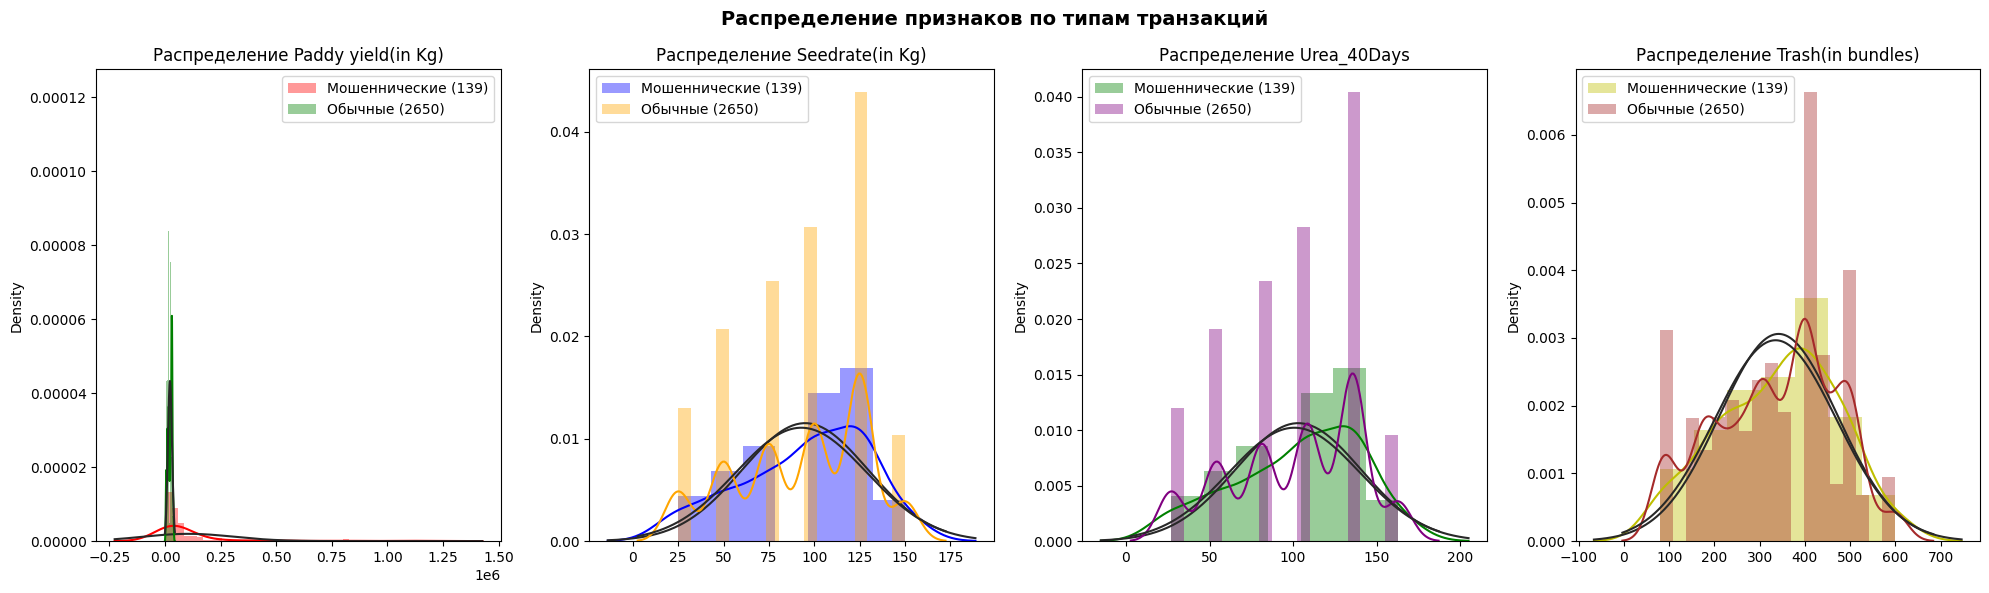

In [43]:
if 'is_fraud' in df_fraud.columns:
    unique_classes = df_fraud['is_fraud'].unique()
    class_col = 'is_fraud'
elif 'class' in df_fraud.columns:
    unique_classes = df_fraud['class'].unique()
    class_col = 'class'
else:
    print("Колонка с метками не найдена!")
    unique_classes = []

print("Уникальные значения в метках:", unique_classes)

if len(unique_classes) == 2:
    fraud_value = 1
    non_fraud_value = 0

    if 1 in unique_classes and 0 in unique_classes:
        fraud_value = 1
        non_fraud_value = 0
    else:
        fraud_value = unique_classes[0]
        non_fraud_value = unique_classes[1]

    print(f"Мошеннические транзакции (класс): {fraud_value}")
    print(f"Обычные транзакции (класс): {non_fraud_value}")

    f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 6))

    yield_col = None
    for col in df_fraud.columns:
        if 'yield' in col.lower() or 'Paddy' in col:
            yield_col = col
            break

    if yield_col:
        yield_fraud_dist = df_fraud[yield_col].loc[df_fraud[class_col] == fraud_value].values
        if len(yield_fraud_dist) > 1:
            sns.distplot(yield_fraud_dist, ax=ax1, fit=norm, color='r',
                        label=f'Мошеннические ({len(yield_fraud_dist)})')
        yield_normal_dist = df_fraud[yield_col].loc[df_fraud[class_col] == non_fraud_value].values
        if len(yield_normal_dist) > 1:
            sns.distplot(yield_normal_dist, ax=ax1, fit=norm, color='g',
                        label=f'Обычные ({len(yield_normal_dist)})')
        ax1.set_title(f'Распределение {yield_col}', fontsize=12)
        ax1.legend()
    seed_col = 'Seedrate(in Kg)' if 'Seedrate(in Kg)' in df_fraud.columns else None
    if seed_col:
        seed_fraud_dist = df_fraud[seed_col].loc[df_fraud[class_col] == fraud_value].values
        if len(seed_fraud_dist) > 1:
            sns.distplot(seed_fraud_dist, ax=ax2, fit=norm, color='b',
                        label=f'Мошеннические ({len(seed_fraud_dist)})')
        seed_normal_dist = df_fraud[seed_col].loc[df_fraud[class_col] == non_fraud_value].values
        if len(seed_normal_dist) > 1:
            sns.distplot(seed_normal_dist, ax=ax2, fit=norm, color='orange',
                        label=f'Обычные ({len(seed_normal_dist)})')
        ax2.set_title(f'Распределение {seed_col}', fontsize=12)
        ax2.legend()
    urea_col = 'Urea_40Days' if 'Urea_40Days' in df_fraud.columns else None
    if urea_col:
        urea_fraud_dist = df_fraud[urea_col].loc[df_fraud[class_col] == fraud_value].values
        if len(urea_fraud_dist) > 1:
            sns.distplot(urea_fraud_dist, ax=ax3, fit=norm, color='g',
                        label=f'Мошеннические ({len(urea_fraud_dist)})')
        urea_normal_dist = df_fraud[urea_col].loc[df_fraud[class_col] == non_fraud_value].values
        if len(urea_normal_dist) > 1:
            sns.distplot(urea_normal_dist, ax=ax3, fit=norm, color='purple',
                        label=f'Обычные ({len(urea_normal_dist)})')
        ax3.set_title(f'Распределение {urea_col}', fontsize=12)
        ax3.legend()
    trash_col = 'Trash(in bundles)' if 'Trash(in bundles)' in df_fraud.columns else None
    if trash_col:
        trash_fraud_dist = df_fraud[trash_col].loc[df_fraud[class_col] == fraud_value].values
        if len(trash_fraud_dist) > 1:
            sns.distplot(trash_fraud_dist, ax=ax4, fit=norm, color='y',
                        label=f'Мошеннические ({len(trash_fraud_dist)})')
        trash_normal_dist = df_fraud[trash_col].loc[df_fraud[class_col] == non_fraud_value].values
        if len(trash_normal_dist) > 1:
            sns.distplot(trash_normal_dist, ax=ax4, fit=norm, color='brown',
                        label=f'Обычные ({len(trash_normal_dist)})')
        ax4.set_title(f'Распределение {trash_col}', fontsize=12)
        ax4.legend()

    plt.suptitle('Распределение признаков по типам транзакций', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print(f"Ожидалось 2 класса, но найдено {len(unique_classes)}: {unique_classes}")

Названия столбцов в датасете:
['Hectares ', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(

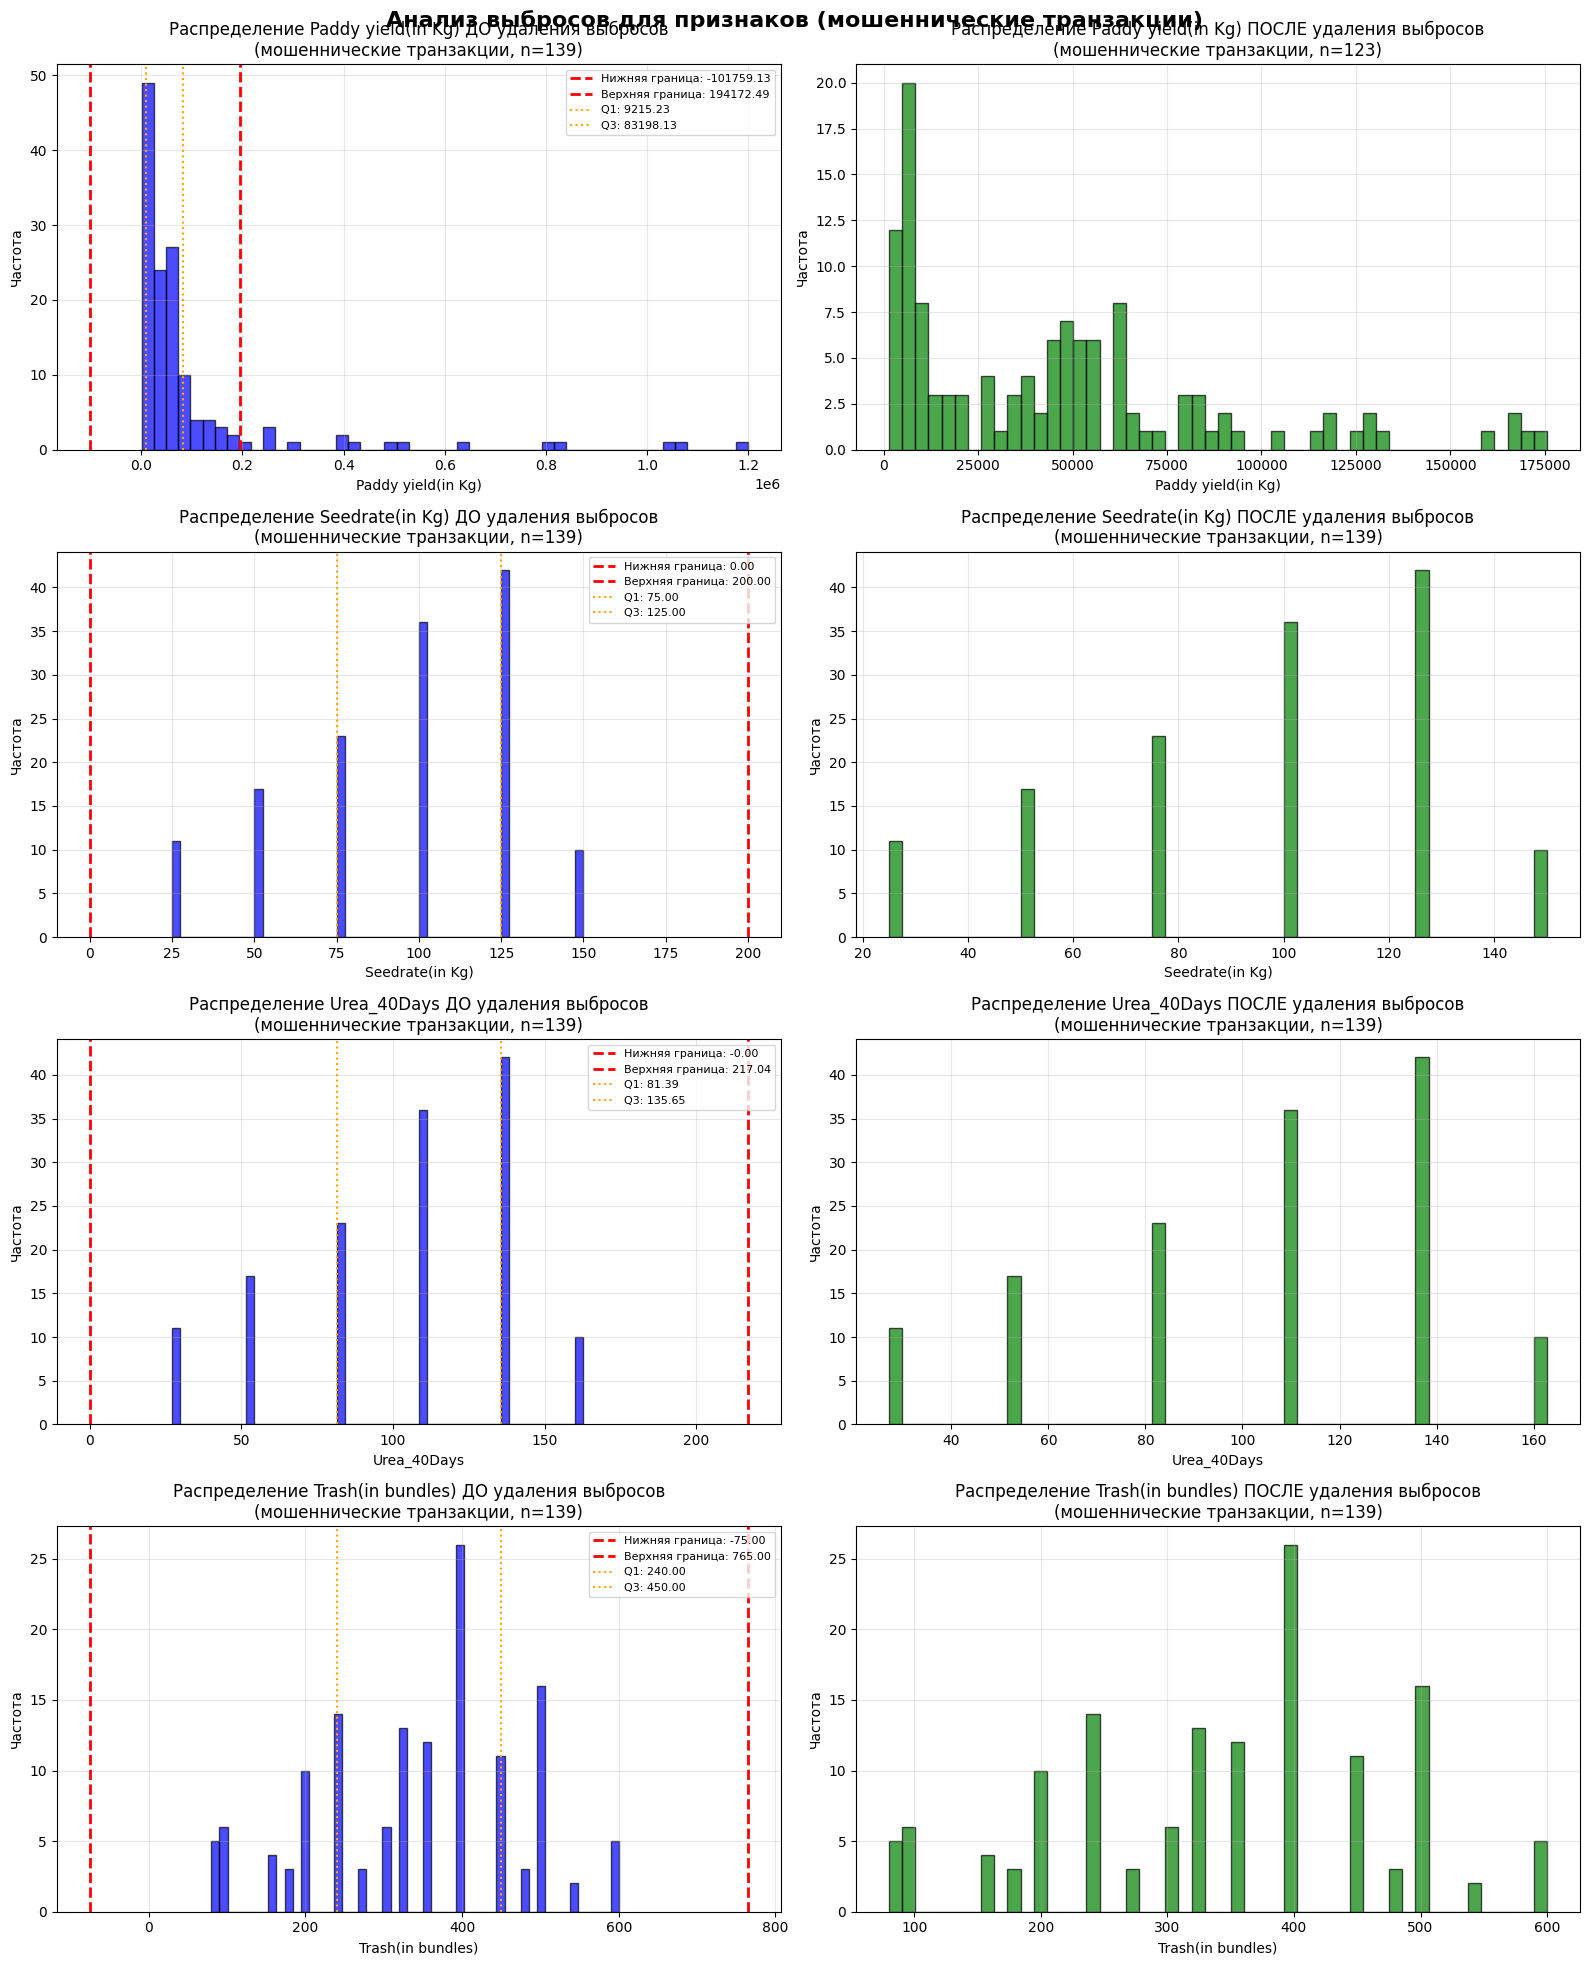

In [45]:
print("Названия столбцов в датасете:")
print(df_fraud.columns.tolist())

if 'is_fraud' in df_fraud.columns:
    class_col = 'is_fraud'
elif 'class' in df_fraud.columns:
    class_col = 'class'
else:
    class_col = None
    print("Колонка с метками не найдена!")

new_df = df_fraud.copy()
if class_col and new_df[class_col].dtype == 'object':
    if 'Low' in new_df[class_col].values:
        new_df[class_col] = new_df[class_col].map({'Low': 0, 'Medium': 1, 'High': 2})
    elif 'P' in new_df[class_col].values or 'H' in new_df[class_col].values:
        new_df[class_col] = new_df[class_col].map({'P': 1, 'H': 0})

features = []
for col in new_df.columns:
    if 'yield' in col.lower() or 'Paddy' in col:
        features.append(col)
        break

features.extend(['Seedrate(in Kg)', 'Urea_40Days', 'Trash(in bundles)'])
features = [f for f in features if f in new_df.columns][:4]

print(f"\nАнализируемые признаки: {features}")

fraud_data = {}
cleaned_data = {}

for feature in features:
    fraud_data[feature] = new_df[feature].loc[new_df[class_col] == 1].values
    if len(fraud_data[feature]) > 0:
        q25, q75 = np.percentile(fraud_data[feature], 25), np.percentile(fraud_data[feature], 75)
        feature_iqr = q75 - q25
        feature_cut_off = feature_iqr * 1.5
        feature_lower, feature_upper = q25 - feature_cut_off, q75 + feature_cut_off
        outliers = [x for x in fraud_data[feature] if x < feature_lower or x > feature_upper]

        new_df_without_outliers = new_df.drop(new_df[(new_df[feature] > feature_upper) |
                                                     (new_df[feature] < feature_lower)].index)
        cleaned_data[feature] = new_df_without_outliers[feature].loc[new_df_without_outliers[class_col] == 1].values
    else:
        cleaned_data[feature] = []

print("\nПостроение графиков для всех признаков")
fig, axes = plt.subplots(len(features), 2, figsize=(16, 5*len(features)))

if len(features) == 1:
    axes = axes.reshape(1, -1)

for idx, feature in enumerate(features):
    if len(fraud_data[feature]) > 0:
        axes[idx, 0].hist(fraud_data[feature], bins=50, color='blue', alpha=0.7, edgecolor='black')

        q25, q75 = np.percentile(fraud_data[feature], 25), np.percentile(fraud_data[feature], 75)
        feature_iqr = q75 - q25
        feature_cut_off = feature_iqr * 1.5
        feature_lower, feature_upper = q25 - feature_cut_off, q75 + feature_cut_off

        axes[idx, 0].axvline(feature_lower, color='red', linestyle='--', linewidth=2,
                            label=f'Нижняя граница: {feature_lower:.2f}')
        axes[idx, 0].axvline(feature_upper, color='red', linestyle='--', linewidth=2,
                            label=f'Верхняя граница: {feature_upper:.2f}')
        axes[idx, 0].axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q1: {q25:.2f}')
        axes[idx, 0].axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q3: {q75:.2f}')

        axes[idx, 0].set_title(f'Распределение {feature} ДО удаления выбросов\n'
                               f'(мошеннические транзакции, n={len(fraud_data[feature])})',
                               fontsize=12)
        axes[idx, 0].set_xlabel(feature, fontsize=10)
        axes[idx, 0].set_ylabel('Частота', fontsize=10)
        axes[idx, 0].legend(fontsize=8)
        axes[idx, 0].grid(True, alpha=0.3)

        if len(cleaned_data[feature]) > 0:
            axes[idx, 1].hist(cleaned_data[feature], bins=50, color='green', alpha=0.7, edgecolor='black')
            axes[idx, 1].set_title(f'Распределение {feature} ПОСЛЕ удаления выбросов\n'
                                   f'(мошеннические транзакции, n={len(cleaned_data[feature])})',
                                   fontsize=12)
        else:
            axes[idx, 1].text(0.5, 0.5, f'Нет данных после очистки',
                             ha='center', va='center', transform=axes[idx, 1].transAxes)
            axes[idx, 1].set_title(f'Распределение {feature} (нет данных)', fontsize=12)

        axes[idx, 1].set_xlabel(feature, fontsize=10)
        axes[idx, 1].set_ylabel('Частота', fontsize=10)
        axes[idx, 1].grid(True, alpha=0.3)

    else:
        axes[idx, 0].text(0.5, 0.5, f'Нет данных для {feature} (мошеннические транзакции)',
                         ha='center', va='center', transform=axes[idx, 0].transAxes)
        axes[idx, 0].set_title(f'Распределение {feature} (нет данных)', fontsize=12)
        axes[idx, 1].text(0.5, 0.5, f'Нет данных для {feature}',
                         ha='center', va='center', transform=axes[idx, 1].transAxes)
        axes[idx, 1].set_title(f'Распределение {feature} (нет данных)', fontsize=12)

plt.suptitle('Анализ выбросов для признаков (мошеннические транзакции)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

ПОДГОТОВКА ДАННЫХ
Используем колонку: 'is_fraud'
Уникальные значения: [0 1]

Всего столбцов в датасете: 46
Числовых столбцов: 38

Размерность исходных данных: (2789, 37)
Количество признаков: 37
Первые 5 признаков: ['Hectares ', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)']

Проверка данных:
NaN значений: 0
Бесконечных значений: 0

Данные после стандартизации:
Среднее: -0.000000
Стандартное отклонение: 1.000000
1. PCA (Principal Component Analysis)
Размерность после PCA: (2789, 37)
Объясненная дисперсия для 37 компонент: 100.00%
Количество компонент для 95% дисперсии: 6


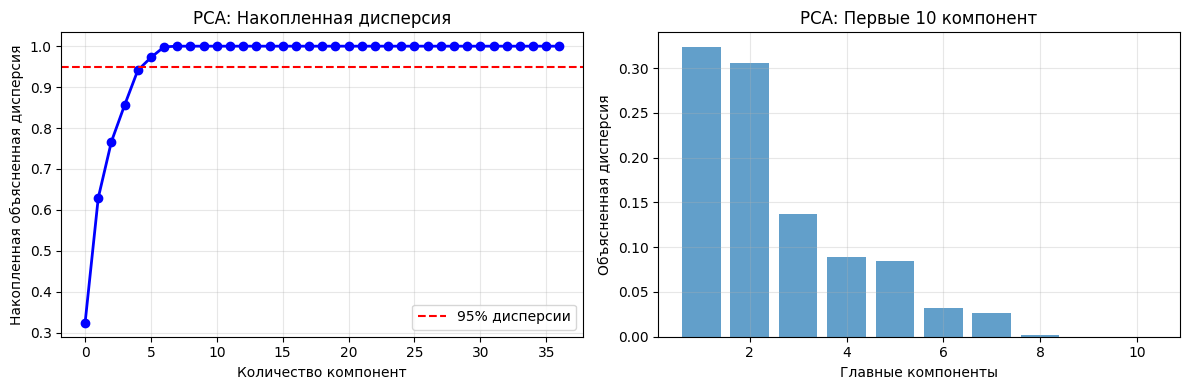

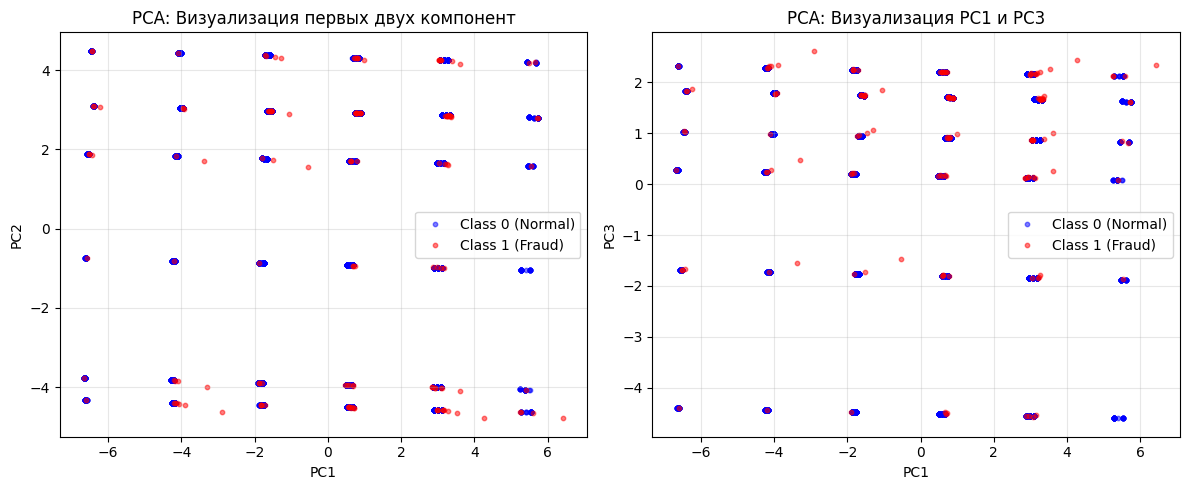

2. t-SNE (t-Distributed Stochastic Neighbor Embedding)
Используется 2000 образцов для t-SNE
Размерность после t-SNE: (2000, 2)


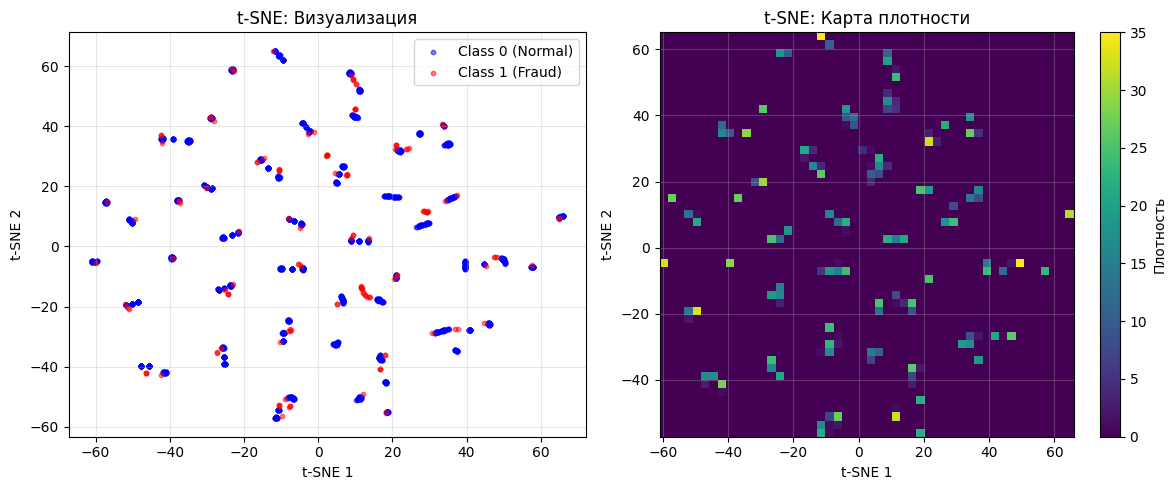

3. Truncated SVD (Singular Value Decomposition)
Размерность после Truncated SVD: (2789, 37)
Объясненная дисперсия для 37 компонент: 100.00%


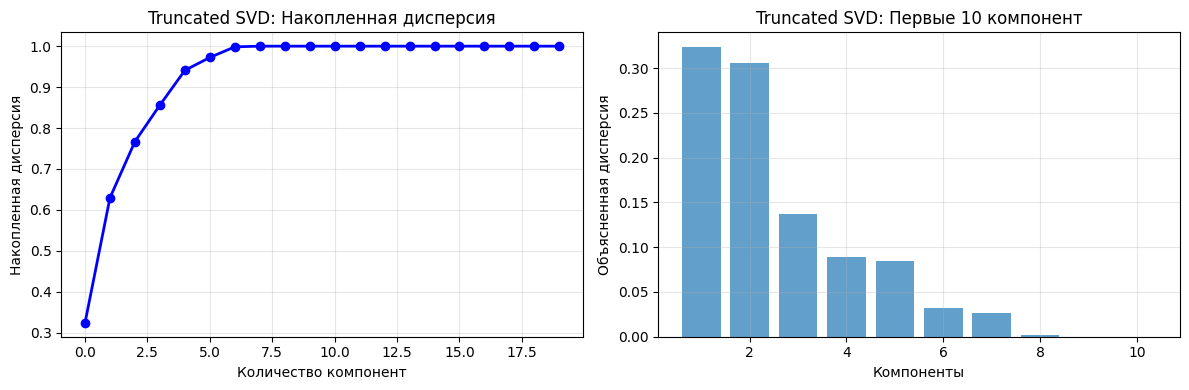

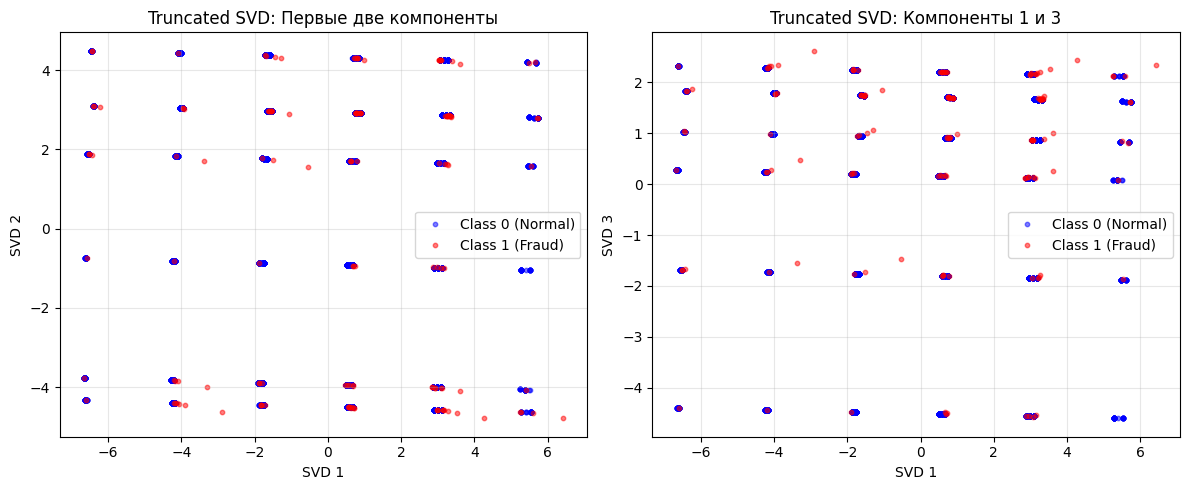

4. КЛАСТЕРИЗАЦИЯ НА ПОНИЖЕННЫХ РАЗМЕРНОСТЯХ

KMeans на PCA:
  Silhouette Score: 0.3009
  Adjusted Rand Index: -0.0004
  Normalized Mutual Information: 0.0002


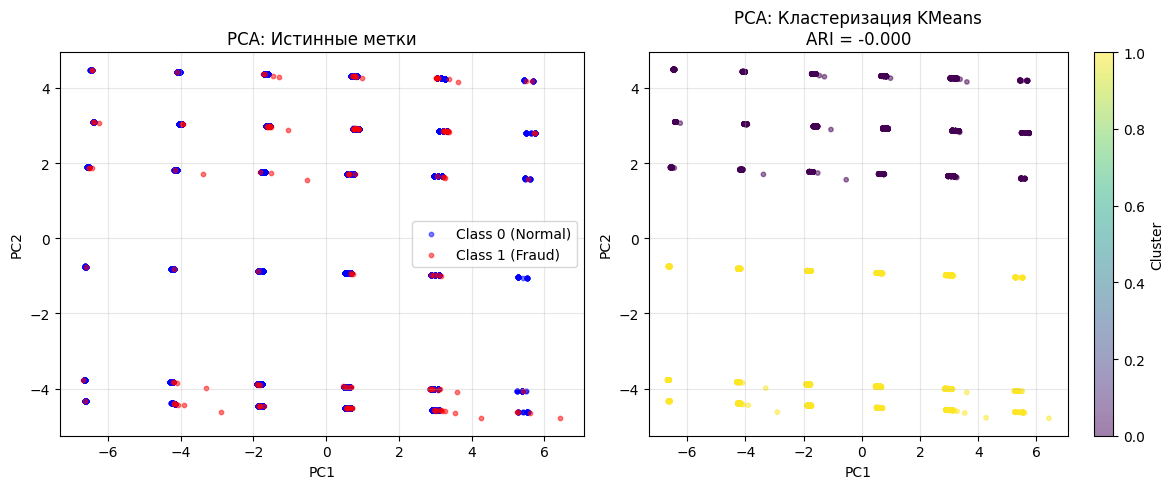


KMeans на t-SNE:
  Silhouette Score: 0.3554
  Adjusted Rand Index: -0.0009
  Normalized Mutual Information: 0.0005


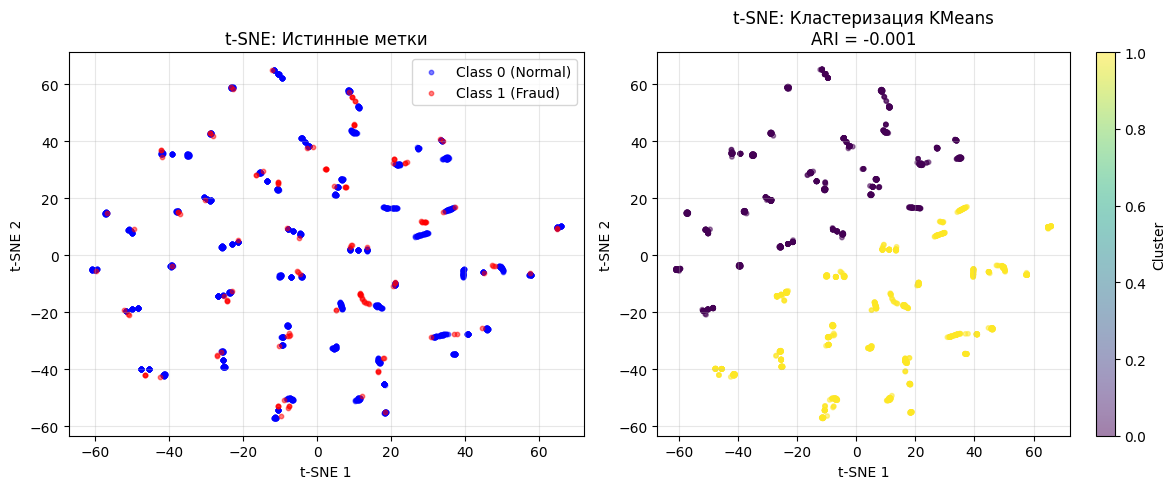


KMeans на Truncated SVD:
  Silhouette Score: 0.3009
  Adjusted Rand Index: -0.0004
  Normalized Mutual Information: 0.0002


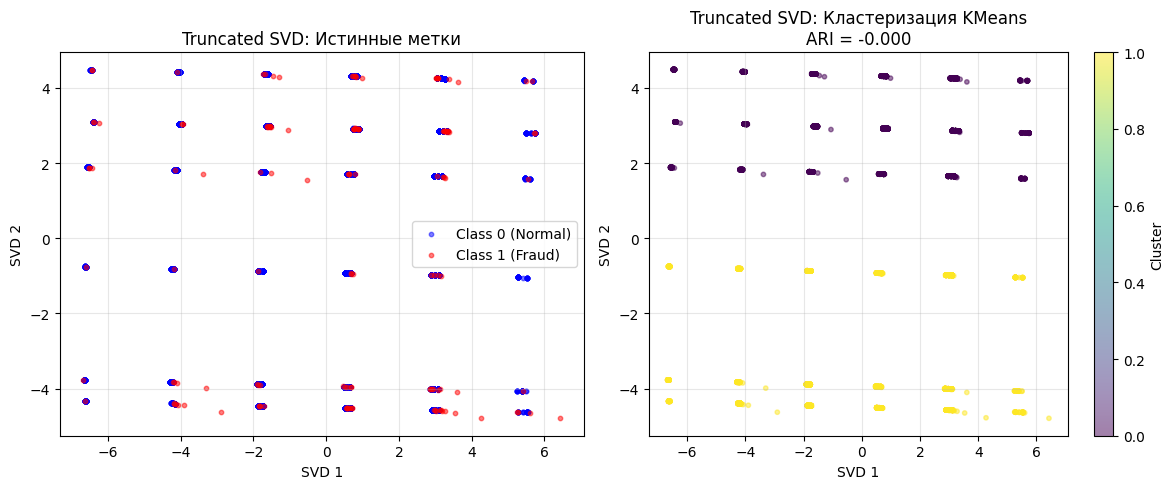

In [47]:
print("ПОДГОТОВКА ДАННЫХ")

new_df = df_fraud.copy()

if 'is_fraud' in new_df.columns:
    class_col = 'is_fraud'
elif 'class' in new_df.columns:
    class_col = 'class'
else:
    class_col = None
    print("Колонка с метками не найдена!")

print(f"Используем колонку: '{class_col}'")
print(f"Уникальные значения: {new_df[class_col].unique()}")

if new_df[class_col].dtype == 'object':
    if 'Low' in new_df[class_col].values:
        new_df[class_col] = new_df[class_col].map({'Low': 0, 'Medium': 1, 'High': 2})
    elif 'P' in new_df[class_col].values or 'H' in new_df[class_col].values:
        new_df[class_col] = new_df[class_col].map({'P': 1, 'H': 0})
    else:
        le = LabelEncoder()
        new_df[class_col] = le.fit_transform(new_df[class_col])

numeric_columns = new_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nВсего столбцов в датасете: {len(new_df.columns)}")
print(f"Числовых столбцов: {len(numeric_columns)}")

if class_col not in numeric_columns:
    print(f"Ошибка: столбец '{class_col}' не является числовым")
    numeric_columns.append(class_col)

feature_columns = [col for col in numeric_columns if col != class_col]
X = new_df[feature_columns].values
y = new_df[class_col].values

print(f"\nРазмерность исходных данных: {X.shape}")
print(f"Количество признаков: {len(feature_columns)}")
print(f"Первые 5 признаков: {feature_columns[:5]}")

print(f"\nПроверка данных:")
print(f"NaN значений: {np.isnan(X).sum()}")
print(f"Бесконечных значений: {np.isinf(X).sum()}")

if np.isnan(X).sum() > 0:
    print("Заполняем NaN значения средними...")
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nДанные после стандартизации:")
print(f"Среднее: {X_scaled.mean():.6f}")
print(f"Стандартное отклонение: {X_scaled.std():.6f}")

print("1. PCA (Principal Component Analysis)")

n_components = min(50, X_scaled.shape[1])
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Размерность после PCA: {X_pca.shape}")
print(f"Объясненная дисперсия для {n_components} компонент: {pca.explained_variance_ratio_.sum():.2%}")

cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Количество компонент для 95% дисперсии: {n_components_95}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cumsum[:min(50, len(cumsum))], 'bo-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('PCA: Накопленная дисперсия')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(1, min(11, len(pca.explained_variance_ratio_) + 1)),
        pca.explained_variance_ratio_[:10], alpha=0.7)
plt.xlabel('Главные компоненты')
plt.ylabel('Объясненная дисперсия')
plt.title('PCA: Первые 10 компонент')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if X_pca.shape[1] >= 2:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    unique_classes = np.unique(y)
    colors = ['blue', 'red', 'green']
    labels = ['Class 0 (Normal)', 'Class 1 (Fraud)']
    if len(unique_classes) > 2:
        labels = [f'Class {c}' for c in unique_classes]

    for i, c in enumerate(unique_classes[:2]):
        plt.scatter(X_pca[y == c, 0], X_pca[y == c, 1],
                   c=colors[i], label=labels[i], alpha=0.5, s=10)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA: Визуализация первых двух компонент')
    plt.legend()
    plt.grid(True, alpha=0.3)

    if X_pca.shape[1] >= 3:
        plt.subplot(1, 2, 2)
        for i, c in enumerate(unique_classes[:2]):
            plt.scatter(X_pca[y == c, 0], X_pca[y == c, 2],
                       c=colors[i], label=labels[i], alpha=0.5, s=10)
        plt.xlabel('PC1')
        plt.ylabel('PC3')
        plt.title('PCA: Визуализация PC1 и PC3')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("2. t-SNE (t-Distributed Stochastic Neighbor Embedding)")

sample_size = min(2000, len(X_scaled))
if len(X_scaled) > sample_size:
    np.random.seed(42)
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_tsne_sample = X_scaled[indices]
    y_tsne_sample = y[indices]
else:
    X_tsne_sample = X_scaled
    y_tsne_sample = y

print(f"Используется {len(X_tsne_sample)} образцов для t-SNE")

tsne = TSNE(n_components=2, random_state=42,
            perplexity=min(30, len(X_tsne_sample)-1), n_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_sample)

print(f"Размерность после t-SNE: {X_tsne.shape}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for i, c in enumerate(np.unique(y_tsne_sample)[:2]):
    plt.scatter(X_tsne[y_tsne_sample == c, 0], X_tsne[y_tsne_sample == c, 1],
               c=colors[i], label=labels[i], alpha=0.5, s=10)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE: Визуализация')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist2d(X_tsne[:, 0], X_tsne[:, 1], bins=50, cmap='viridis')
plt.colorbar(label='Плотность')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE: Карта плотности')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("3. Truncated SVD (Singular Value Decomposition)")

n_svd_components = min(50, X_scaled.shape[1])
svd = TruncatedSVD(n_components=n_svd_components, random_state=42, n_iter=10)
X_svd = svd.fit_transform(X_scaled)

explained_variance_ratio_svd = svd.explained_variance_ratio_
cumsum_svd = np.cumsum(explained_variance_ratio_svd)

print(f"Размерность после Truncated SVD: {X_svd.shape}")
print(f"Объясненная дисперсия для {n_svd_components} компонент: {cumsum_svd[-1]:.2%}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cumsum_svd[:20], 'bo-', linewidth=2)
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Truncated SVD: Накопленная дисперсия')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(range(1, min(11, len(explained_variance_ratio_svd) + 1)),
        explained_variance_ratio_svd[:10], alpha=0.7)
plt.xlabel('Компоненты')
plt.ylabel('Объясненная дисперсия')
plt.title('Truncated SVD: Первые 10 компонент')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if X_svd.shape[1] >= 2:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for i, c in enumerate(np.unique(y)[:2]):
        plt.scatter(X_svd[y == c, 0], X_svd[y == c, 1],
                   c=colors[i], label=labels[i], alpha=0.5, s=10)
    plt.xlabel('SVD 1')
    plt.ylabel('SVD 2')
    plt.title('Truncated SVD: Первые две компоненты')
    plt.legend()
    plt.grid(True, alpha=0.3)

    if X_svd.shape[1] >= 3:
        plt.subplot(1, 2, 2)
        for i, c in enumerate(np.unique(y)[:2]):
            plt.scatter(X_svd[y == c, 0], X_svd[y == c, 2],
                       c=colors[i], label=labels[i], alpha=0.5, s=10)
        plt.xlabel('SVD 1')
        plt.ylabel('SVD 3')
        plt.title('Truncated SVD: Компоненты 1 и 3')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("4. КЛАСТЕРИЗАЦИЯ НА ПОНИЖЕННЫХ РАЗМЕРНОСТЯХ")

def cluster_and_evaluate(X_reduced, y_true, method_name):
    try:
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        y_pred = kmeans.fit_predict(X_reduced)
        silhouette = silhouette_score(X_reduced, y_pred)
        ari = adjusted_rand_score(y_true, y_pred)
        nmi = normalized_mutual_info_score(y_true, y_pred)
        print(f"\n{method_name}:")
        print(f"  Silhouette Score: {silhouette:.4f}")
        print(f"  Adjusted Rand Index: {ari:.4f}")
        print(f"  Normalized Mutual Information: {nmi:.4f}")
        return y_pred, kmeans
    except Exception as e:
        print(f"\n{method_name}: Ошибка - {e}")
        return None, None

if X_pca.shape[1] >= 2:
    y_pred_pca, kmeans_pca = cluster_and_evaluate(X_pca[:, :min(10, X_pca.shape[1])], y, "KMeans на PCA")
    if y_pred_pca is not None:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        for i, c in enumerate(np.unique(y)[:2]):
            plt.scatter(X_pca[y == c, 0], X_pca[y == c, 1],
                       c=colors[i], label=labels[i], alpha=0.5, s=10)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title('PCA: Истинные метки')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_pca, cmap='viridis', alpha=0.5, s=10)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title(f'PCA: Кластеризация KMeans\nARI = {adjusted_rand_score(y, y_pred_pca):.3f}')
        plt.colorbar(label='Cluster')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if X_tsne.shape[0] == len(y_tsne_sample):
    y_pred_tsne, kmeans_tsne = cluster_and_evaluate(X_tsne, y_tsne_sample, "KMeans на t-SNE")
    if y_pred_tsne is not None:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        for i, c in enumerate(np.unique(y_tsne_sample)[:2]):
            plt.scatter(X_tsne[y_tsne_sample == c, 0], X_tsne[y_tsne_sample == c, 1],
                       c=colors[i], label=labels[i], alpha=0.5, s=10)
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        plt.title('t-SNE: Истинные метки')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred_tsne, cmap='viridis', alpha=0.5, s=10)
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        plt.title(f't-SNE: Кластеризация KMeans\nARI = {adjusted_rand_score(y_tsne_sample, y_pred_tsne):.3f}')
        plt.colorbar(label='Cluster')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if X_svd.shape[1] >= 2:
    y_pred_svd, kmeans_svd = cluster_and_evaluate(X_svd[:, :min(10, X_svd.shape[1])], y, "KMeans на Truncated SVD")
    if y_pred_svd is not None:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        for i, c in enumerate(np.unique(y)[:2]):
            plt.scatter(X_svd[y == c, 0], X_svd[y == c, 1],
                       c=colors[i], label=labels[i], alpha=0.5, s=10)
        plt.xlabel('SVD 1')
        plt.ylabel('SVD 2')
        plt.title('Truncated SVD: Истинные метки')
        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y_pred_svd, cmap='viridis', alpha=0.5, s=10)
        plt.xlabel('SVD 1')
        plt.ylabel('SVD 2')
        plt.title(f'Truncated SVD: Кластеризация KMeans\nARI = {adjusted_rand_score(y, y_pred_svd):.3f}')
        plt.colorbar(label='Cluster')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()